In [5]:
%cd /content
!rm -rf rainfall_kf
!git clone https://github.com/Felix-Schwer/rainfall_kf.git
%cd rainfall_kf
!pip install -e .
!pip install -q spotpy

import xarray as xr
import pandas as pd
import numpy as np
import spotpy
import matplotlib.pyplot as plt

from rainfall_kf.models.hbvedu import processed_inputs_fromds, HBVTransition, HBVObservation
from rainfall_kf.models.hbv2 import SJV_Sierra_UBParameters, SJV_Sierra_LBParameters, SJV_Valley_UBParameters, SJV_Valley_LBParameters


%cd /content/rainfall_kf/data

prism_ds = xr.open_dataset('prism_basin_means.nc')
gpm_ds = xr.open_dataset('gpm_basin_means.nc')
et_ds = xr.open_dataset('et_basin_means.nc')
temp_ds = xr.open_dataset('temp_basin_means.nc')
stream_ds = xr.open_dataset('streamflow.nc')

et_ds, (monthly_et, monthly_temp) = processed_inputs_fromds(et_ds, temp_ds, starttime='2000-01-01', endtime='2020-12-31')


stations_in_basin = {
    "18040001": ["11273400"], "18040002": ["11274550"], "18040003": ["11303500"],
    "18040006": [], "18040007": [], "18040008": ["11272500"],
    "18040009": ["11290000"], "18040010": ["11303000"], "18040011": [],
    "18040012": ["11325500"], "18040013": [], "18040014": ["11255575"]
}

basin_id = "18040009" # Upper Tuolumne
station_id = stations_in_basin[basin_id][0]
start_time = stream_ds.sel(site=station_id).continuous_start
end_time = stream_ds.sel(site=station_id).continuous_end

inputs = np.array([
    temp_ds.tmean.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    gpm_ds.precipitation.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    monthly_temp.sel(basin=basin_id, time=slice(start_time, end_time)).values,
    monthly_et.sel(basin=basin_id, time=slice(start_time, end_time)).values
])

times = stream_ds.streamflow.sel(site=station_id, time=slice(start_time, end_time)).time.values
observations_imperial = np.array([stream_ds.streamflow.sel(site=station_id, time=slice(start_time, end_time)).values])

cfs_to_m3s = 0.0283168
sqmi_to_km2 = 2.58999
basin_area_km2 = stream_ds.sel(site=station_id).drainage_area.values * sqmi_to_km2
observations = observations_imperial * cfs_to_m3s / basin_area_km2 # m3/s/km2
observations = observations * 86400 / 1000000 * 1000 # m/day

# Establish the Factory Blueprint Base
Valley_Params = 0.5 * (SJV_Valley_UBParameters + SJV_Valley_LBParameters)
Sierra_Params = 0.5 * (SJV_Sierra_UBParameters + SJV_Sierra_LBParameters)
Params = 0.5 * Sierra_Params + (1 - 0.5) * Valley_Params




/content
Cloning into 'rainfall_kf'...
remote: Enumerating objects: 393, done.
remote: Counting objects: 100% (248/248), done.
remote: Compressing objects: 100% (178/178), done.
remote: Total 393 (delta 139), reused 153 (delta 69), pack-reused 145 (from 1)
Receiving objects: 100% (393/393), 113.65 MiB | 34.67 MiB/s, done.
Resolving deltas: 100% (175/175), done.
/content/rainfall_kf
Obtaining file:///content/rainfall_kf
  Preparing metadata (setup.py) ... done
  Running setup.py develop for rainfall_kf
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 42.1 MB/s eta 0:00:00
/content/rainfall_kf/data


In [17]:
def peak_flow_error(obs, sim, percentile=90):

    threshold = np.percentile(obs, percentile)

    mask = obs >= threshold

    if np.sum(mask) == 0:
        return 0.0

    relative_error = np.abs(
        obs[mask] - sim[mask]
    ) / (obs[mask] + 1e-6)

    return np.mean(relative_error)


def weighted_rmse(obs, sim):
    # higher penalty on large flows
    threshold = np.percentile(obs, 90)
    weights = np.where(obs >= threshold, 1.5, 1.0)
    return np.sqrt(np.mean(weights * (obs - sim)**2))

In [20]:
class Direct_SJV_Calibration:
    def __init__(self, observed_flow, inputs_k, initial_state):
        # ranges are from the 2000 Seibert paper, could change it based on our data, we can calibrate other parameters as needed
        # maybe we can just use ALPHA to make things easier?
        self.params = [
            spotpy.parameter.Uniform('d', low=1.0, high=10.0),
            spotpy.parameter.Uniform('fc', low=200, high=500),
            spotpy.parameter.Uniform('beta', low=1.0, high=6.0),
            spotpy.parameter.Uniform('k0', low=0.001, high=0.03),
            spotpy.parameter.Uniform('k1', low=0.0005, high=0.02),
            spotpy.parameter.Uniform('k2', low=0.0001, high=0.005),
            spotpy.parameter.Uniform('tt', low=-1.5, high=2.5),
            spotpy.parameter.Uniform('l', low=1.0, high=15.0)
        ]

        self.observations = observed_flow
        self.inputs_k = inputs_k
        self.x0 = initial_state
        self.k_steps = inputs_k.shape[1]

    def parameters(self):
        return spotpy.parameter.generate(self.params)

    def simulation(self, vector):
        # Unpack the guessed parameters
        d_guess, fc_guess, beta_guess, k0_guess, k1_guess, k2_guess, tt_guess, l_guess = vector
        HBV_Blueprint = type(Params)
        test_params = HBV_Blueprint(
            d=d_guess,
            fc=fc_guess,
            beta=beta_guess,
            c=0.0316,
            k0=k0_guess,
            l=l_guess,
            k1=k1_guess,
            k2=k2_guess,
            kp=0.0367,
            pwp=164.45,
            tt=tt_guess

        )



        x = self.x0.copy()
        simulated_q = np.zeros(self.k_steps)

        for k in range(self.k_steps):

            u_k = self.inputs_k[:, k:k+1]

            x = HBVTransition(x, u_k, test_params)

            simulated_q[k] = HBVObservation(x, test_params).item()

        return simulated_q

    def evaluation(self):

        return self.observations[0, :]

    def objectivefunction(self, simulation, evaluation,params=None):
        valid_idx = ~np.isnan(evaluation)
        sim_valid = simulation[valid_idx]
        eval_valid = evaluation[valid_idx]

        # PENALTY for completely broken arrays
        if len(sim_valid) == 0: return 999999.0

        # Calculate Metrics
        nse = spotpy.objectivefunctions.nashsutcliffe(eval_valid, sim_valid)
        sim_log = np.where(sim_valid <= 0, 1e-6, sim_valid)
        eval_log = np.where(eval_valid <= 0, 1e-6, eval_valid)
        log_nse = spotpy.objectivefunctions.nashsutcliffe(eval_log, sim_log)

        pbias = spotpy.objectivefunctions.pbias(eval_valid, sim_valid)
        peak_err = peak_flow_error(eval_valid, sim_valid)
        w_rmse = weighted_rmse(eval_valid, sim_valid)

        # Normalize components
        max_q = np.max(eval_valid) if np.max(eval_valid) > 0 else 1.0
        peak_norm = peak_err / max_q
        w_rmse_norm = w_rmse / max_q

        # Minimize this positive cost toward 0.0
        cost = (
            0.50 * (1 - nse)
            + 0.2 * (1 - log_nse)
            + 0.2 * abs(pbias)/100
            +0.05 * peak_norm
            +0.05 * w_rmse_norm

        )
        return cost

Initializing the  Shuffled Complex Evolution (SCE-UA) algorithm  with  200  repetitions
The objective function will be minimized
Starting burn-in sampling...
Initialize database...
['csv', 'hdf5', 'ram', 'sql', 'custom', 'noData']
* Database file 'SJV_Direct_Calibration.csv' created.
3 of 200, minimal objective function=0.370214, time remaining: 00:01:58
6 of 200, minimal objective function=0.370214, time remaining: 00:02:06
9 of 200, minimal objective function=0.286531, time remaining: 00:02:05
12 of 200, minimal objective function=0.286531, time remaining: 00:02:06
15 of 200, minimal objective function=0.286531, time remaining: 00:02:08
17 of 200, minimal objective function=0.286531, time remaining: 00:02:20
21 of 200, minimal objective function=0.286531, time remaining: 00:02:14
24 of 200, minimal objective function=0.286531, time remaining: 00:02:10
28 of 200, minimal objective function=0.286531, time remaining: 00:02:05
31 of 200, minimal objective function=0.286531, time remainin

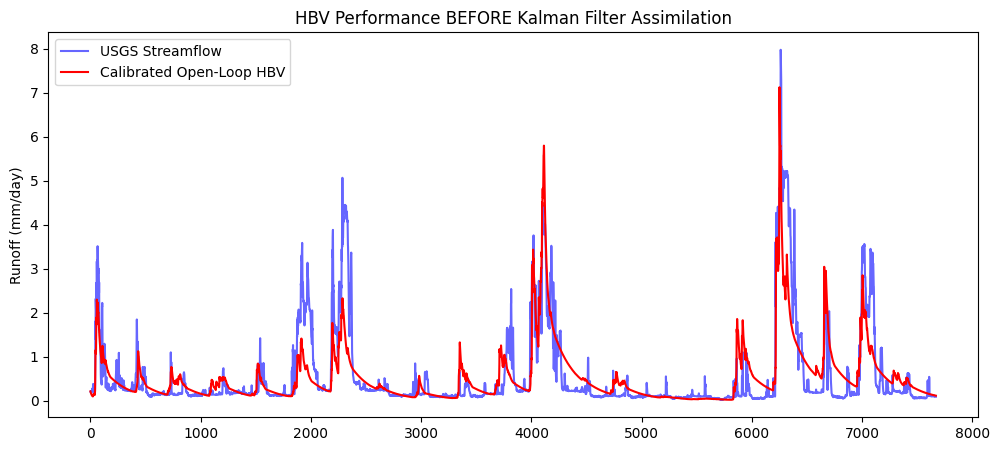

In [21]:
calibration_setup = Direct_SJV_Calibration(
    observed_flow=observations,
    inputs_k=inputs,
    # initial value, I put random numbers here
    initial_state=np.array([[0., 100., 10., 10., 10.]]).T
)

# find the best parameters
sampler = spotpy.algorithms.sceua(calibration_setup, dbname='SJV_Direct_Calibration', dbformat='csv')
sampler.sample(200)

# get best parameters
results = spotpy.analyser.load_csv_results('SJV_Direct_Calibration')

best_index = np.argmin(results['like1'])
print(f"Best Multi-Criteria Score: {results['like1'][best_index]:.3f}")

# final parameters
HBV_Blueprint = type(Params)
final_calibrated_params = HBV_Blueprint(
    d=results['pard'][best_index],
    fc=results['parfc'][best_index],
    beta=results['parbeta'][best_index],
    c=0.0316,
    k0=results['park0'][best_index],
    l=results['parl'][best_index],
    k1=results['park1'][best_index],
    k2=results['park2'][best_index],
    kp=0.0367,
    pwp=164.45,
    tt=results['partt'][best_index]
)

print(f"\nFinal Parameters:\n{final_calibrated_params}")

# Plot the best run
best_sim = calibration_setup.simulation([
    results['pard'][best_index],
    results['parfc'][best_index],
    results['parbeta'][best_index],
    results['park0'][best_index],
    results['park1'][best_index],
    results['park2'][best_index],
    results['partt'][best_index],
    results['parl'][best_index]
])


plt.figure(figsize=(12, 5))
plt.plot(observations[0, :], color='blue', alpha=0.6, label='USGS Streamflow')
plt.plot(best_sim, color='red', linewidth=1.5, label='Calibrated Open-Loop HBV')
plt.title('HBV Performance BEFORE Kalman Filter Assimilation')
plt.ylabel('Runoff (mm/day)')
plt.legend()
plt.show()